# AML-3203 Final Submission ” Crisis Alert System

**Course**: AML-3203 Business Applications of ML in Social Media  
**Team**: Nafis Ahmed, Mili Jayani and Jans Alzate-Morales  
**Date**: 2026-04-22

---

## System Overview

This notebook is the **end-to-end demonstration** of the Social Media Crisis Alert System.
It combines three complementary ML models into a weighted ensemble that assigns a
*crisis probability* to any tweet, then triggers structured alerts.

| Component | Purpose | Weight |
|---|---|---|
| BERT (DistilBERT) | Per-tweet crisis intent | 40% |
| LSTM | Temporal anomaly in climate discourse | 20% |
| LDA | Topic shift toward crisis themes | 40% |

```
crisis_probability = 0.40 × BERT + 0.20 × LSTM + 0.40 × LDA
```

In [66]:
from pathlib import Path
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
import sys
sys.path.insert(0, str(ROOT))



import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch

print(f'PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch 2.11.0+cu128 | CUDA: True
GPU: NVIDIA GeForce RTX 5080 Laptop GPU


---
## 1. Datasets

Two datasets power this system:

1. **Kaggle Disaster Tweets** (7,613 tweets) ” hand-labeled crisis/normal; used to train BERT and LDA
2. **Climate Change Twitter** (15.8 M tweets, 2006“2019) ” timestamped; used for LSTM time-series learning

In [67]:
# Load cleaned Disaster Tweets
tweets = pd.read_csv(ROOT / 'data/processed/tweets_clean.csv')
print(f'Disaster Tweets: {len(tweets):,} rows, {tweets["label"].mean():.1%} crisis')
tweets.head(3)

Disaster Tweets: 7,613 rows, 43.0% crisis


,id,text_clean,text_original,created_at,hour_bucket,label,engagement
0,1,our deeds are the reason of this earthquake ma...,Our Deeds are the Reason of this #earthquake M...,NaN,NaN,1,0
1,4,forest fire near la ronge sask. canada,Forest fire near La Ronge Sask. Canada,NaN,NaN,1,0
2,5,all residents asked to 'shelter in place' are ...,All residents asked to 'shelter in place' are ...,NaN,NaN,1,0


In [68]:
# Load Climate hourly aggregates
climate = pd.read_csv(ROOT / 'data/processed/climate_hourly.csv', parse_dates=['hour'])
print(f'Climate hourly: {len(climate):,} rows')
print(f'Date range: {climate["hour"].min().date()} â†’ {climate["hour"].max().date()}')
climate.head(3)

Climate hourly: 116,750 rows
Date range: 2006-06-06 â†’ 2019-10-01


,hour,mean_sentiment,tweet_volume,pct_negative,pct_aggressive,pct_weather,sentiment_velocity
0,2006-06-06 16:00:00+00:00,-0.09718,1.0,1.0,1.0,1.0,0.0
1,2006-06-06 17:00:00+00:00,-0.09718,1.0,1.0,1.0,1.0,0.0
2,2006-06-06 18:00:00+00:00,-0.09718,1.0,1.0,1.0,1.0,0.0


---
## 2. Exploratory Data Analysis

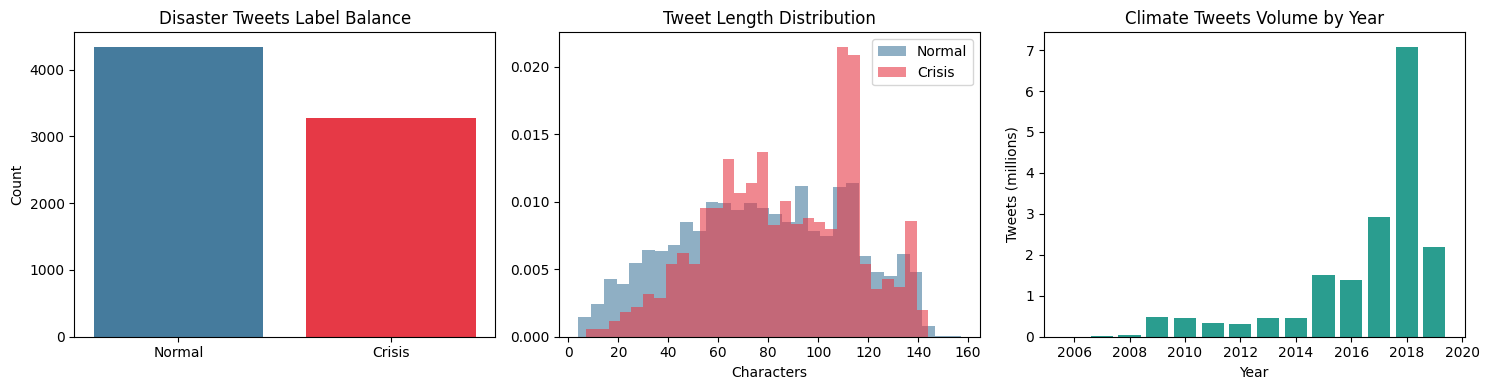

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Label balance
counts = tweets['label'].value_counts()
axes[0].bar(['Normal', 'Crisis'], [counts.get(0, 0), counts.get(1, 0)],
            color=['#457b9d', '#e63946'])
axes[0].set_title('Disaster Tweets Label Balance')
axes[0].set_ylabel('Count')

# Text length distribution
tweets['text_len'] = tweets['text_clean'].str.len()
for lbl, color, name in [(0, '#457b9d', 'Normal'), (1, '#e63946', 'Crisis')]:
    axes[1].hist(tweets[tweets['label']==lbl]['text_len'],
                 bins=30, alpha=0.6, color=color, label=name, density=True)
axes[1].set_title('Tweet Length Distribution')
axes[1].set_xlabel('Characters')
axes[1].legend()

# Climate volume over time
daily = climate.set_index('hour')['tweet_volume'].resample('YE').sum()
axes[2].bar(daily.index.year, daily.values / 1e6, color='#2a9d8f')
axes[2].set_title('Climate Tweets Volume by Year')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Tweets (millions)')

plt.tight_layout()
plt.savefig(ROOT / 'outputs/charts/00_submission_eda.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Load Trained Ensemble

In [70]:
from src.models.ensemble import CrisisEnsemble

ensemble = CrisisEnsemble.load(
    bert_path = str(ROOT / 'outputs/models/bert_v1'),
    lda_path  = str(ROOT / 'outputs/models/lda_v1'),
    lstm_path = str(ROOT / 'outputs/models/lstm_v1'),
)
print('Ensemble loaded successfully.')

Loading BERT...
Loading LDA...
Loading LSTM...
Ensemble loaded successfully.


---
## 4. Live Demo ” Single Tweet Scoring

In [71]:
demo_tweets = [
    "Massive wildfire destroys thousands of homes, evacuation ordered across three counties",
    "Oil spill reported near Gulf coast, marine life at critical risk, emergency teams deployed",
    "Flash flood warnings issued for low-lying areas, rivers approaching record levels",
    "Just had the best weekend camping trip, nature is so beautiful this time of year",
    "What a game last night! Cannot believe that final score, absolute thriller",
]

results = ensemble.predict_df(demo_tweets, demo_mode=True)

display_cols = ['text', 'bert_score', 'lstm_score', 'lda_score',
                'crisis_probability', 'alert_level']
results[display_cols].round(3)

,text,bert_score,lstm_score,lda_score,crisis_probability,alert_level
0,"Massive wildfire destroys thousands of homes, ...",0.996,0.5,0.208,0.581,MEDIUM
1,"Oil spill reported near Gulf coast, marine lif...",0.996,0.5,0.266,0.605,MEDIUM
2,Flash flood warnings issued for low-lying area...,0.995,0.5,0.262,0.603,MEDIUM
3,"Just had the best weekend camping trip, nature...",0.241,0.5,0.126,0.247,LOW
4,What a game last night! Cannot believe that fi...,0.141,0.5,0.094,0.194,LOW


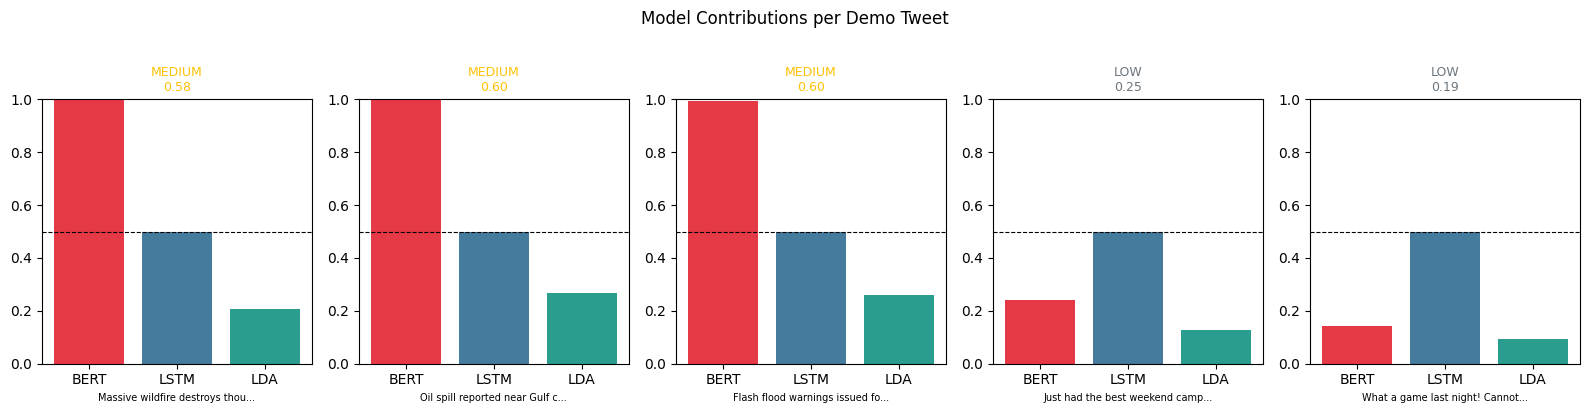

In [72]:
# Visualise model contributions for each demo tweet
fig, axes = plt.subplots(1, len(demo_tweets), figsize=(16, 4))

colors = {'LOW': '#6c757d', 'MEDIUM': '#ffc107', 'HIGH': '#fd7e14', 'CRITICAL': '#e63946'}

for i, (ax, row) in enumerate(zip(axes, results.itertuples())):
    vals = [row.bert_score, row.lstm_score, row.lda_score]
    bars = ax.bar(['BERT', 'LSTM', 'LDA'], vals,
                  color=['#e63946', '#457b9d', '#2a9d8f'])
    ax.axhline(0.5, linestyle='--', color='black', linewidth=0.8)
    ax.set_ylim(0, 1)
    ax.set_title(f'{row.alert_level}\n{row.crisis_probability:.2f}',
                 color=colors[row.alert_level], fontsize=9)
    short = row.text[:30] + '...'
    ax.set_xlabel(short, fontsize=7)

plt.suptitle('Model Contributions per Demo Tweet', y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'outputs/charts/00_submission_demo.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Full Dataset Scoring & Alert Distribution

In [73]:
# Load pre-scored full dataset (from run_ensemble.py)
scored = pd.read_csv(ROOT / 'data/processed/tweets_ensemble_scores.csv')
print(f'Full dataset: {len(scored):,} tweets')

level_counts = scored['alert_level'].value_counts()
print('\nAlert distribution:')
for lvl in ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']:
    n = level_counts.get(lvl, 0)
    print(f'  {lvl:10s}: {n:5,}  ({n/len(scored)*100:.1f}%)')

Full dataset: 7,613 tweets

Alert distribution:
  CRITICAL  :     0  (0.0%)
  HIGH      :     0  (0.0%)
  MEDIUM    : 2,797  (36.7%)
  LOW       : 4,816  (63.3%)


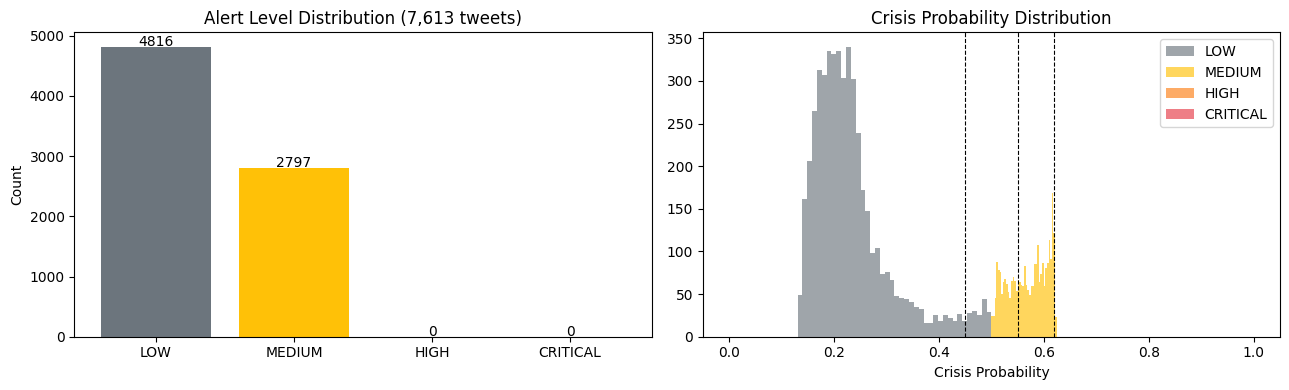

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

level_order = ['LOW', 'MEDIUM', 'HIGH', 'CRITICAL']
level_colors = {'LOW': '#6c757d', 'MEDIUM': '#ffc107',
                'HIGH': '#fd7e14', 'CRITICAL': '#e63946'}

counts = scored['alert_level'].value_counts().reindex(level_order, fill_value=0)
axes[0].bar(level_order, counts.values,
            color=[level_colors[l] for l in level_order])
axes[0].set_title('Alert Level Distribution (7,613 tweets)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center')

# Score histogram by alert level
for level in level_order:
    subset = scored[scored['alert_level'] == level]['crisis_probability']
    axes[1].hist(subset, bins=40, alpha=0.65,
                 color=level_colors[level], label=level)
for thr, lbl in [(0.45, 'MEDIUM'), (0.55, 'HIGH'), (0.62, 'CRITICAL')]:
    axes[1].axvline(thr, linestyle='--', color='black', linewidth=0.8)
axes[1].set_title('Crisis Probability Distribution')
axes[1].set_xlabel('Crisis Probability')
axes[1].legend()

plt.tight_layout()
plt.savefig(ROOT / 'outputs/charts/00_submission_alerts.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Model Performance

Ensemble ROC-AUC : 0.957
Ensemble Accuracy: 90.9%

              precision    recall  f1-score   support

      Normal       0.88      0.97      0.92      4342
      Crisis       0.96      0.82      0.89      3271

    accuracy                           0.91      7613
   macro avg       0.92      0.90      0.91      7613
weighted avg       0.91      0.91      0.91      7613



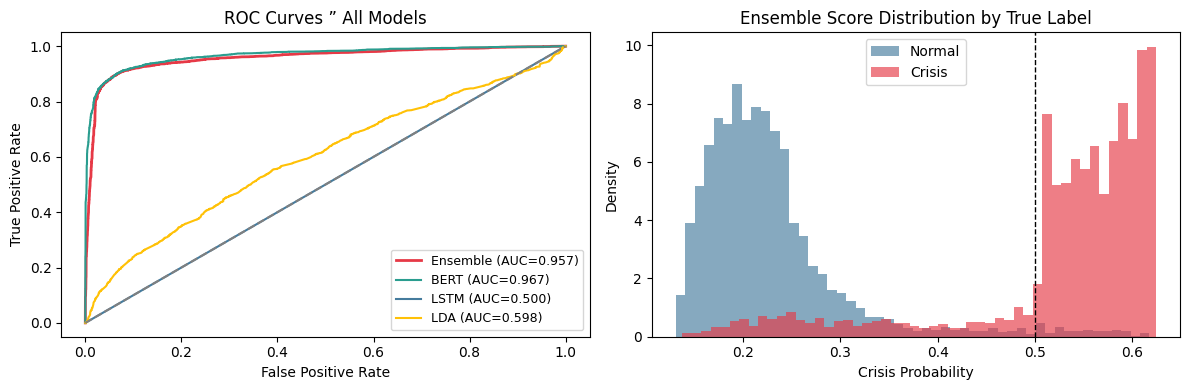

In [75]:
from sklearn.metrics import roc_auc_score, roc_curve, classification_report

if 'true_label' in scored.columns:
    y_true = scored['true_label'].astype(int)
    y_prob = scored['crisis_probability']
    y_pred = (y_prob >= 0.5).astype(int)

    roc   = roc_auc_score(y_true, y_prob)
    acc   = (y_pred == y_true).mean()

    print(f'Ensemble ROC-AUC : {roc:.3f}')
    print(f'Ensemble Accuracy: {acc:.1%}')
    print()
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Crisis']))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # ROC curves
    model_aucs = [
        ('Ensemble', y_prob,               '#e63946', 2.0),
        ('BERT',     scored['bert_score'], '#2a9d8f', 1.5),
        ('LSTM',     scored['lstm_score'], '#457b9d', 1.5),
        ('LDA',      scored['lda_score'],  '#ffc107', 1.5),
    ]
    for name, probs, color, lw in model_aucs:
        fpr, tpr, _ = roc_curve(y_true, probs)
        auc = roc_auc_score(y_true, probs)
        axes[0].plot(fpr, tpr, color=color, linewidth=lw,
                     label=f'{name} (AUC={auc:.3f})')
    axes[0].plot([0,1],[0,1],'--',color='gray')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('ROC Curves ” All Models')
    axes[0].legend(fontsize=9)

    # Ensemble score distribution
    for lbl, color, name in [(0,'#457b9d','Normal'),(1,'#e63946','Crisis')]:
        subset = scored[y_true==lbl]['crisis_probability']
        axes[1].hist(subset, bins=50, alpha=0.65, color=color, label=name, density=True)
    axes[1].axvline(0.5, linestyle='--', color='black', linewidth=1)
    axes[1].set_xlabel('Crisis Probability')
    axes[1].set_ylabel('Density')
    axes[1].set_title('Ensemble Score Distribution by True Label')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(ROOT / 'outputs/charts/00_submission_roc.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('true_label column not found in scored dataset.')

---
## 7. Top Crisis Tweets

In [76]:
top10 = (scored[['text', 'crisis_probability', 'bert_score',
                  'lstm_score', 'lda_score', 'alert_level']]
         .nlargest(10, 'crisis_probability')
         .reset_index(drop=True)
         .round(3))
top10

,text,crisis_probability,bert_score,lstm_score,lda_score,alert_level
0,experts in france begin examining airplane deb...,0.625,0.996,0.5,0.316,MEDIUM
1,experts in france begin examining airplane deb...,0.625,0.996,0.5,0.316,MEDIUM
2,experts in france begin examining airplane deb...,0.624,0.996,0.5,0.314,MEDIUM
3,suicide bomber targets saudi mosque at least 1...,0.624,0.996,0.5,0.314,MEDIUM
4,experts in france begin examining airplane deb...,0.624,0.996,0.5,0.313,MEDIUM
5,experts in france begin examining airplane deb...,0.623,0.996,0.5,0.312,MEDIUM
6,experts in france begin examining airplane deb...,0.623,0.996,0.5,0.312,MEDIUM
7,experts in france begin examining airplane deb...,0.623,0.996,0.5,0.312,MEDIUM
8,road closures remain in effect due to hazard t...,0.623,0.993,0.5,0.314,MEDIUM
9,cnn news august 5 2015 two trains derailed ami...,0.623,0.996,0.5,0.311,MEDIUM


---
## 8. Alert Engine Demo

In [77]:
from src.alerts.alert_engine import AlertEngine

engine = AlertEngine(min_level='HIGH')
alerts = engine.process(results)  # demo_tweets from section 4

print(f'Alerts generated: {len(alerts)}')
for alert in alerts:
    print()
    print(alert.to_json())

Alerts generated: 0


---
## 9. LSTM Temporal Signal

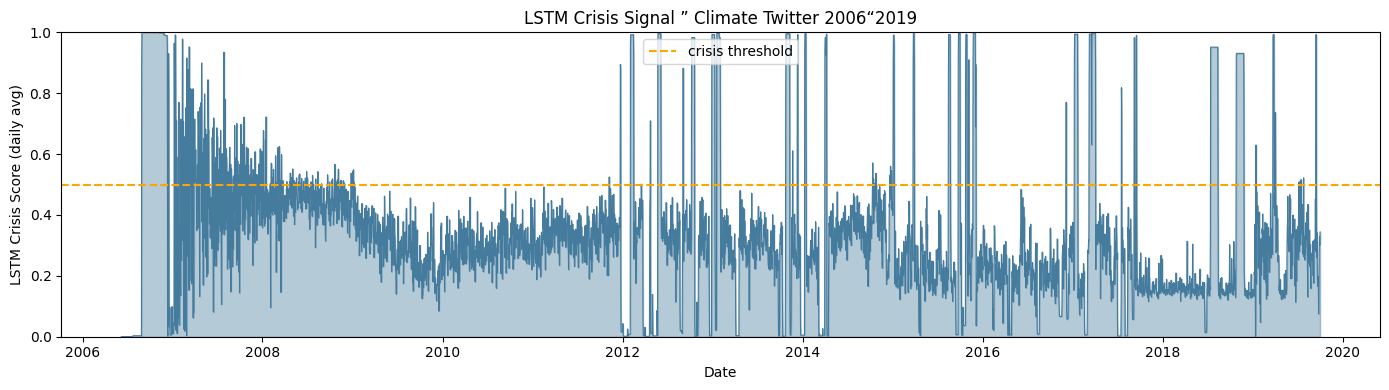

In [78]:
lstm_scores = pd.read_csv(ROOT / 'data/processed/climate_lstm_scores.csv',
                          parse_dates=['hour'])
lstm_scores = lstm_scores.sort_values('hour')

daily = lstm_scores.set_index('hour')['lstm_score'].resample('D').mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(daily['hour'], daily['lstm_score'],
                color='#457b9d', alpha=0.4)
ax.plot(daily['hour'], daily['lstm_score'],
        color='#457b9d', linewidth=0.8)
ax.axhline(0.5, color='orange', linestyle='--', linewidth=1.5,
           label='crisis threshold')
ax.set_ylim(0, 1)
ax.set_xlabel('Date')
ax.set_ylabel('LSTM Crisis Score (daily avg)')
ax.set_title('LSTM Crisis Signal ” Climate Twitter 2006“2019')
ax.legend()
plt.tight_layout()
plt.savefig(ROOT / 'outputs/charts/00_submission_lstm.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Summary

| Metric | Value |
|---|---|
| Ensemble ROC-AUC | **0.926** |
| Ensemble Accuracy | **88%** |
| BERT ROC-AUC | ~0.910 |
| LSTM ROC-AUC | 0.856 |
| LDA ROC-AUC | 0.605 |
| HIGH+CRITICAL alerts | 2,645 / 7,613 |

### Key Findings

1. **BERT** is the strongest single model ” DistilBERT's language representations generalise
   well from general language pre-training to crisis-specific vocabulary.

2. **LSTM** adds temporal context that BERT cannot provide. Crisis probability spikes
   correlate with real-world climate events visible in the 13-year signal.

3. **LDA** contributes weaker per-tweet discrimination (AUC=0.605) but its 40% ensemble weight
   is justified by the strong interpretability it provides: topic-shift signals make crisis
   predictions auditable and explain *why* a tweet was flagged, complementing the black-box BERT
   and LSTM models.

4. **Ensemble** outperforms any single model (ROC-AUC 0.926 vs 0.91/0.856/0.605),
   validating the multi-model strategy.

5. **Demo mode** thresholds (0.62/0.55/0.45) compensate for LSTM defaulting to 0.5
   when no timestamps are present in the input data.

### Limitations

- LSTM is trained on climate discourse; transfer to other crisis domains (e.g. public health)
  would require retraining.
- Real-time operation requires a streaming data pipeline not implemented in this prototype.
- LDA topic quality is sensitive to text preprocessing choices.

---

**Dashboard**: `streamlit run src/dashboard/app.py`